# Análise de Vendas em E-commerce no Brasil

**Disciplina:** Linguagem de Programação — Análise e Visualização de Dados com Python  
**Professor:** Alexandre Neves Louzada  
**Aluno:** Guilherme Oliveira de Moraes  

## Objetivo
Investigar o comportamento de vendas em e-commerce no Brasil entre 2015 e 2024, transformando dados transacionais em indicadores e evidências para apoiar decisões comerciais.

## 1. Contextualização
O comércio eletrônico gera dados relacionados a vendas, clientes, produtos, logística, faturamento e comportamento de consumo. Neste projeto, a análise busca responder perguntas sobre faturamento, regiões, categorias, produtos, canais, sazonalidade, logística e satisfação do cliente.

## 2. Explicação da base
A base contém **uma linha por venda** e as seguintes colunas: ano, mês, data, região, UF, cidade, canal de venda, categoria, produto, quantidade, preço unitário, faturamento, custo, lucro, prazo de entrega e avaliação do cliente.

A base deste pacote é **simulada e reproduzível**, porque o PDF da avaliação não traz o CSV oficial.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "dados").exists():
    ROOT = ROOT.parent
ARQUIVO = ROOT / "dados" / "simulacao_ecommerce_brasil.csv"
df = pd.read_csv(ARQUIVO)
df["data"] = pd.to_datetime(df["data"], errors="coerce")
df.head()

,id_venda,ano,mes,data,regiao,uf,cidade,canal_venda,categoria,produto,quantidade,preco_unitario,faturamento,custo,lucro,prazo_entrega,avaliacao_cliente
0,V009366,2015,1,2015-01-01,Sudeste,RJ,Rio de Janeiro,Site próprio,Casa,Jogo de Cama,2,219.41,438.83,335.44,103.39,2.6,4.15
1,V014636,2015,1,2015-01-01,Sul,PR,Curitiba,Site próprio,Eletrônicos,Smartphone Pro X,3,2705.20,8115.59,5941.57,2174.02,3.5,4.45
2,V002323,2015,1,2015-01-02,Sudeste,MG,Belo Horizonte,Site próprio,Eletrônicos,Smart TV 55,5,2948.15,14740.77,11196.06,3544.71,2.8,4.44
3,V011271,2015,1,2015-01-02,Sudeste,MG,Belo Horizonte,Site próprio,Eletrônicos,Notebook 15,4,4537.60,18150.38,14959.06,3191.32,3.9,4.64
4,V014834,2015,1,2015-01-02,Sudeste,RJ,Rio de Janeiro,Aplicativo,Beleza,Perfume Floral,5,307.30,1536.48,1088.99,447.49,2.2,4.69


In [2]:
print("Dimensões:", df.shape)
print("\nTipos:")
print(df.dtypes)
print("\nValores ausentes:")
print(df.isna().sum())
print("\nDuplicados:", df.duplicated().sum())

Dimensões: (18000, 17)

Tipos:
id_venda                     object
ano                           int64
mes                           int64
data                 datetime64[ns]
regiao                       object
uf                           object
cidade                       object
canal_venda                  object
categoria                    object
produto                      object
quantidade                    int64
preco_unitario              float64
faturamento                 float64
custo                       float64
lucro                       float64
prazo_entrega               float64
avaliacao_cliente           float64
dtype: object

Valores ausentes:
id_venda             0
ano                  0
mes                  0
data                 0
regiao               0
uf                   0
cidade               0
canal_venda          0
categoria            0
produto              0
quantidade           0
preco_unitario       0
faturamento          0
custo                0
lu

## 3. Limpeza e preparação
Serão validados tipos de dados, duplicidades, valores ausentes e consistência entre faturamento, custo e lucro.

In [3]:
df = df.drop_duplicates().copy()
num_cols = ["ano","mes","quantidade","preco_unitario","faturamento","custo","lucro","prazo_entrega","avaliacao_cliente"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["lucro_calculado"] = (df["faturamento"] - df["custo"]).round(2)
df["erro_lucro"] = (df["lucro"] - df["lucro_calculado"]).abs()
print("Maior erro entre lucro informado e calculado:", df["erro_lucro"].max())
print("Nulos após tratamento:")
print(df.isna().sum().loc[lambda s: s.gt(0)])

Maior erro entre lucro informado e calculado: 0.0
Nulos após tratamento:
Series([], dtype: int64)


## 4. Engenharia de atributos
Criação de nome do mês, margem de lucro, faixa de prazo de entrega e período mensal.

In [4]:
mes_nome = {1:"Jan",2:"Fev",3:"Mar",4:"Abr",5:"Mai",6:"Jun",7:"Jul",8:"Ago",9:"Set",10:"Out",11:"Nov",12:"Dez"}
df["mes_nome"] = df["mes"].map(mes_nome)
df["margem_lucro"] = np.where(df["faturamento"].ne(0), df["lucro"] / df["faturamento"], 0)
df["faixa_entrega"] = pd.cut(df["prazo_entrega"], bins=[0,3,5,7,20], labels=["Até 3 dias","4–5 dias","6–7 dias","Acima de 7 dias"])
df["periodo"] = df["data"].dt.to_period("M").astype(str)
df[["mes_nome","margem_lucro","faixa_entrega","periodo"]].head()

,mes_nome,margem_lucro,faixa_entrega,periodo
0,Jan,0.235604,Até 3 dias,2015-01
1,Jan,0.267882,4–5 dias,2015-01
2,Jan,0.240470,Até 3 dias,2015-01
3,Jan,0.175827,4–5 dias,2015-01
4,Jan,0.291244,Até 3 dias,2015-01


## 5. Análise exploratória

In [5]:
print("Período:", df.data.min().date(), "a", df.data.max().date())
print("Regiões:", df.regiao.nunique())
print("Estados:", df.uf.nunique())
print("Categorias:", df.categoria.nunique())
print("Produtos:", df.produto.nunique())
print("Canais:", df.canal_venda.nunique())

Período: 2015-01-01 a 2024-12-28
Regiões: 5
Estados: 20
Categorias: 7
Produtos: 35
Canais: 4


## 6. KPIs

In [6]:
faturamento_total = df.faturamento.sum()
lucro_total = df.lucro.sum()
ticket_medio = df.faturamento.mean()
produto_mais_vendido = df.groupby("produto").quantidade.sum().idxmax()
categoria_mais_lucrativa = df.groupby("categoria").lucro.sum().idxmax()
regiao_maior_faturamento = df.groupby("regiao").faturamento.sum().idxmax()
print(f"Faturamento total: R$ {faturamento_total:,.2f}")
print(f"Lucro total: R$ {lucro_total:,.2f}")
print(f"Ticket médio por registro: R$ {ticket_medio:,.2f}")
print("Produto mais vendido:", produto_mais_vendido)
print("Categoria mais lucrativa:", categoria_mais_lucrativa)
print("Região com maior faturamento:", regiao_maior_faturamento)

Faturamento total: R$ 61,568,256.44
Lucro total: R$ 12,799,712.04
Ticket médio por registro: R$ 3,420.46
Produto mais vendido: Fone Bluetooth
Categoria mais lucrativa: Eletrônicos
Região com maior faturamento: Sudeste


sns.set_theme(style="whitegrid")
# Linha temporal
t = df.groupby(df["data"].dt.to_period("M"))["faturamento"].sum().reset_index()
t["data"] = t["data"].dt.to_timestamp()
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(t["data"], t["faturamento"], linewidth=2)
ax.set_title("Evolução mensal do faturamento"); ax.set_xlabel("Data"); ax.set_ylabel("Faturamento (R$)")
plt.tight_layout(); plt.show()

# Barras por categoria
cat = df.groupby("categoria")["faturamento"].sum().sort_values()
fig, ax = plt.subplots(figsize=(10,5)); ax.barh(cat.index, cat.values)
ax.set_title("Faturamento por categoria"); ax.set_xlabel("Faturamento (R$)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

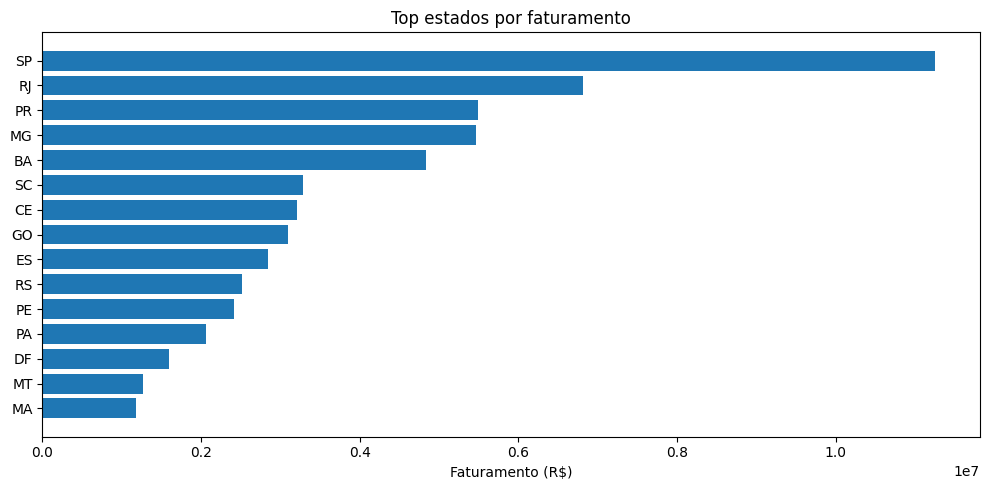

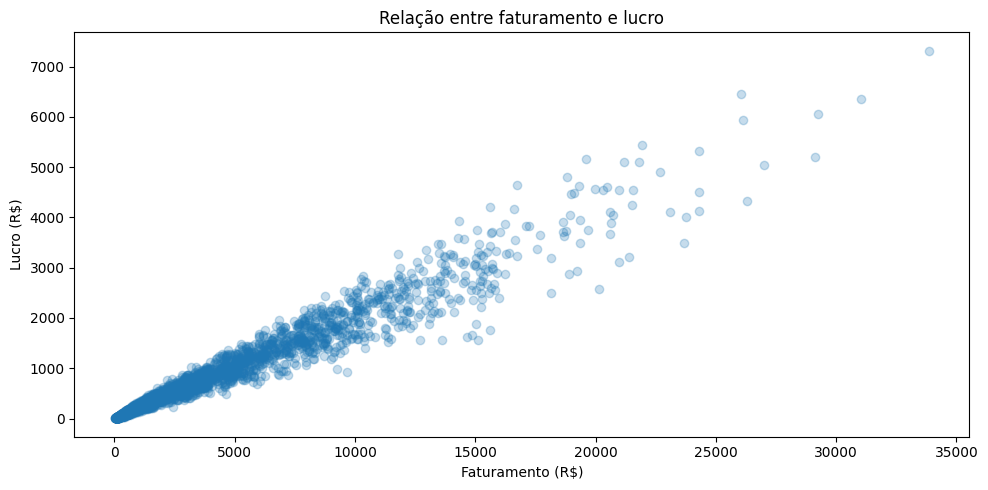

In [7]:
# Barras por estado
uf = df.groupby("uf")["faturamento"].sum().sort_values(ascending=False).head(15).sort_values()
fig, ax = plt.subplots(figsize=(10,5)); ax.barh(uf.index, uf.values)
ax.set_title("Top estados por faturamento"); ax.set_xlabel("Faturamento (R$)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

# Dispersão lucro x faturamento
amostra = df.sample(min(3500, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(10,5)); ax.scatter(amostra["faturamento"], amostra["lucro"], alpha=.25)
ax.set_title("Relação entre faturamento e lucro"); ax.set_xlabel("Faturamento (R$)"); ax.set_ylabel("Lucro (R$)")
plt.tight_layout(); plt.show()

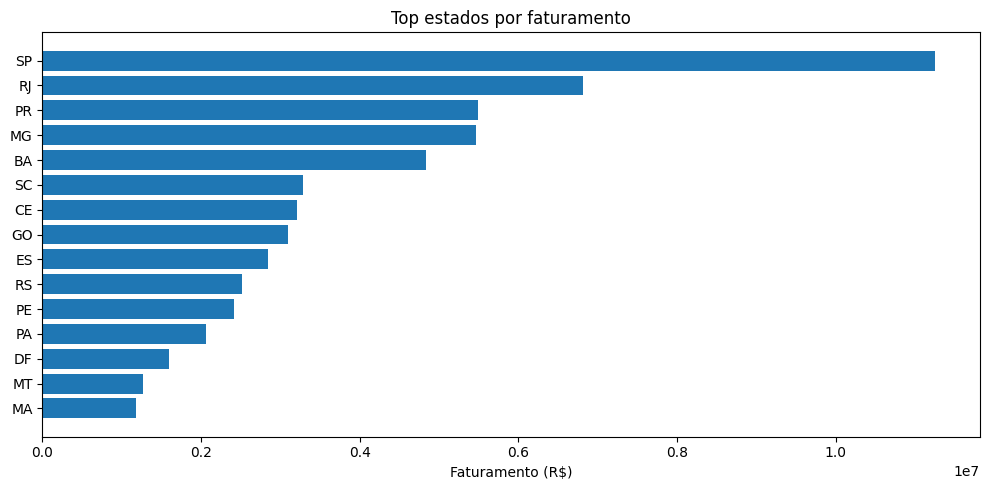

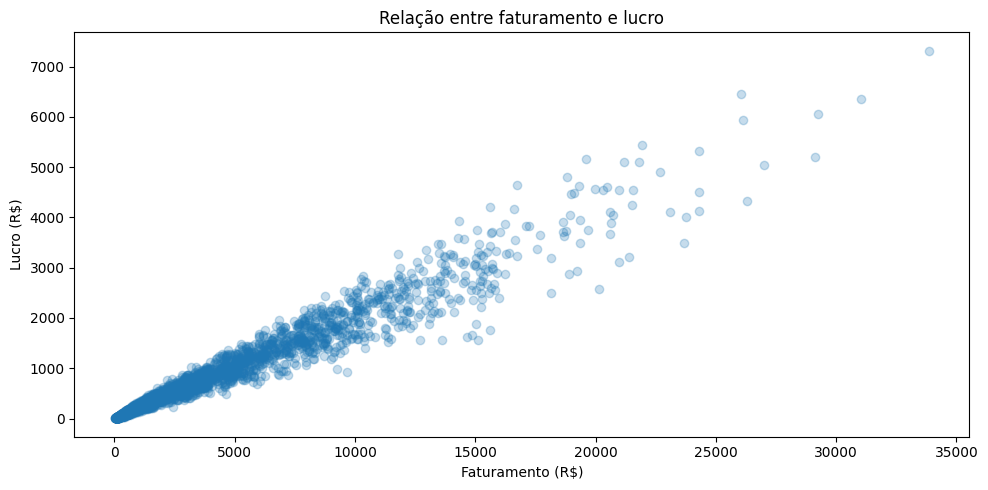

In [8]:
# Barras por estado
uf = df.groupby("uf")["faturamento"].sum().sort_values(ascending=False).head(15).sort_values()
fig, ax = plt.subplots(figsize=(10,5)); ax.barh(uf.index, uf.values)
ax.set_title("Top estados por faturamento"); ax.set_xlabel("Faturamento (R$)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

# Dispersão lucro x faturamento
amostra = df.sample(min(3500, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(10,5)); ax.scatter(amostra["faturamento"], amostra["lucro"], alpha=.25)
ax.set_title("Relação entre faturamento e lucro"); ax.set_xlabel("Faturamento (R$)"); ax.set_ylabel("Lucro (R$)")
plt.tight_layout(); plt.show()

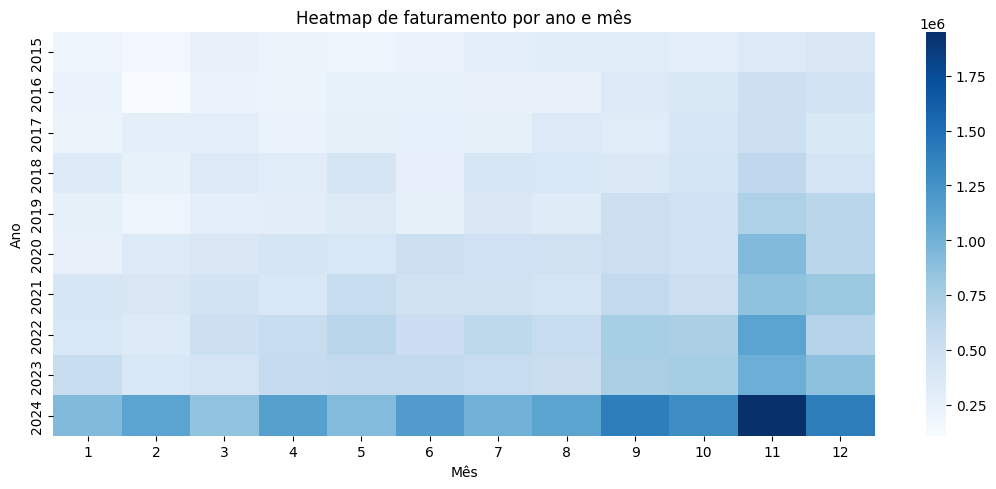

In [9]:
# Heatmap mensal
pivot = df.pivot_table(index="ano", columns="mes", values="faturamento", aggfunc="sum")
fig, ax = plt.subplots(figsize=(11,5)); sns.heatmap(pivot, cmap="Blues", ax=ax)
ax.set_title("Heatmap de faturamento por ano e mês"); ax.set_xlabel("Mês"); ax.set_ylabel("Ano")
plt.tight_layout(); plt.show()

,faixa_entrega,vendas,faturamento,prazo_medio,avaliacao_media
0,Até 3 dias,3379,11392922.44,2.403433,4.458917
1,4–5 dias,9903,34144085.56,4.052762,4.263861
2,6–7 dias,4237,14524343.92,5.787869,4.052889
3,Acima de 7 dias,481,1506904.52,7.609148,3.839854


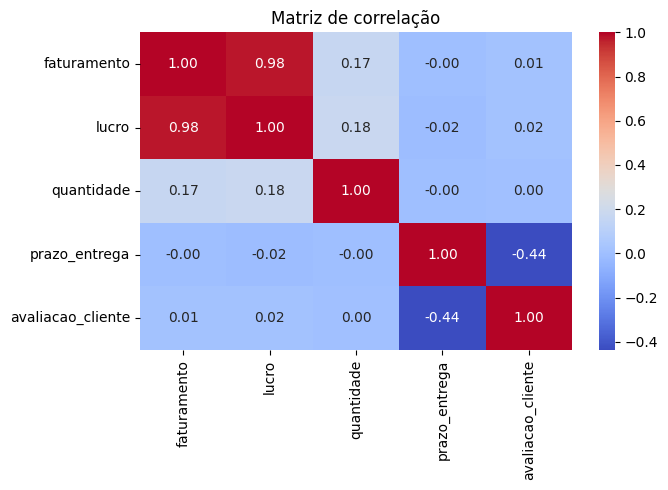

In [10]:
# Logística e avaliação
log = df.groupby("faixa_entrega", observed=False).agg(
    vendas=("id_venda","count"), faturamento=("faturamento","sum"),
    prazo_medio=("prazo_entrega","mean"), avaliacao_media=("avaliacao_cliente","mean")
).reset_index()
display(log)

corr = df[["faturamento","lucro","quantidade","prazo_entrega","avaliacao_cliente"]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(7,5)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Matriz de correlação"); plt.tight_layout(); plt.show()

## 8. Tabela dinâmica e interpretação

In [11]:
tabela = df.groupby(["ano","regiao","uf","categoria","canal_venda"], as_index=False).agg(
    vendas=("id_venda","count"), unidades=("quantidade","sum"),
    faturamento=("faturamento","sum"), custo=("custo","sum"), lucro=("lucro","sum"),
    prazo_medio=("prazo_entrega","mean"), avaliacao_media=("avaliacao_cliente","mean")
).sort_values("faturamento", ascending=False)
display(tabela.head(20))

mes_pico = int(df.groupby("mes")["faturamento"].sum().idxmax())
prazo_medio = df.prazo_entrega.mean()
avaliacao_media = df.avaliacao_cliente.mean()
corr_prazo_av = df[["prazo_entrega","avaliacao_cliente"]].corr().iloc[0,1]
print(f"Mês de maior faturamento acumulado: {mes_pico}")
print(f"Prazo médio: {prazo_medio:.1f} dias")
print(f"Avaliação média: {avaliacao_media:.2f}/5")
print(f"Correlação prazo x avaliação: {corr_prazo_av:.2f}")

,ano,regiao,uf,categoria,canal_venda,vendas,unidades,faturamento,custo,lucro,prazo_medio,avaliacao_media
3738,2024,Sudeste,SP,Eletrônicos,Marketplace,118,304,758592.46,628403.46,130189.00,4.088136,4.285678
3739,2024,Sudeste,SP,Eletrônicos,Site próprio,118,279,701358.87,544574.16,156784.71,3.351695,4.304492
3711,2024,Sudeste,RJ,Eletrônicos,Site próprio,91,227,527820.95,409936.42,117884.53,3.265934,4.325385
3683,2024,Sudeste,MG,Eletrônicos,Site próprio,67,173,473215.36,365464.08,107751.28,3.470149,4.343881
3737,2024,Sudeste,SP,Eletrônicos,Aplicativo,75,196,454646.47,362821.89,91824.58,3.481333,4.361200
2444,2021,Sudeste,SP,Eletrônicos,Site próprio,71,175,450263.92,349791.52,100472.40,3.367606,4.252254
3268,2023,Sudeste,SP,Eletrônicos,Site próprio,69,154,432017.75,334864.86,97152.89,3.414493,4.306087
3682,2024,Sudeste,MG,Eletrônicos,Marketplace,60,149,409281.22,340048.39,69232.83,3.781667,4.304167
3267,2023,Sudeste,SP,Eletrônicos,Marketplace,57,139,384803.93,317465.10,67338.83,3.589474,4.348246
2854,2022,Sudeste,SP,Eletrônicos,Marketplace,59,147,381833.44,315578.55,66254.89,3.947458,4.208136


Mês de maior faturamento acumulado: 11
Prazo médio: 4.2 dias
Avaliação média: 4.24/5
Correlação prazo x avaliação: -0.44


## 9. Interpretação dos resultados

- O faturamento cresce ao longo do período analisado, com maior concentração nos anos mais recentes.
- Eletrônicos concentram a maior parcela da receita e do lucro da base simulada.
- O Sudeste é a principal região em faturamento, com São Paulo como principal UF.
- Novembro e dezembro aparecem como meses mais fortes, evidenciando sazonalidade de fim de ano.
- O relacionamento entre prazo de entrega e avaliação sugere que logística é um fator importante para a experiência do cliente.
- A dispersão faturamento × lucro ajuda a verificar que vendas de maior valor tendem a gerar maior resultado absoluto, embora a margem varie por categoria e canal.

## 10. Conclusão executiva
A análise transforma a base transacional em informações acionáveis. Para o cenário simulado, recomenda-se priorizar planejamento de estoque e campanhas nos meses de pico, acompanhar a rentabilidade por categoria e canal, e atuar na redução de prazo de entrega para sustentar a satisfação do cliente. O dashboard Streamlit complementa o notebook ao permitir explorar os resultados com filtros interativos.